# Extract stock data from Yahoo Finance

Here’s a full modular pipeline in Python that:

Downloads daily price data and resamples quarterly

Extracts key quarterly momentum features

Fetches quarterly fundamental and other features from yfinance

Handles missing data smartly

Creates a binary target variable (buy/sell) based on future returns

Returns a flat DataFrame ready for ML modeling



Function defitions:

* get_price_features: downloads daily data, resamples quarterly, computes returns, volatility, momentum.

* get_fundamental_features: grabs the latest fundamentals, institutional holdings, ESG, dividends, recommendations.

* build_quarterly_dataset: merges both, cleans missing values, creates a binary future return target.



#### TODO
* MACD calculation (# All Supported Ta-lib indicators: https://github.com/TA-Lib/ta-lib-python/blob/master/docs/funcs.md)


In [1]:
#!pip install pandas_datareader

In [2]:
import yfinance as yf
import pandas_datareader as pdr

import pandas as pd
import numpy as np

from datetime import datetime
import datetime

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [3]:
notebook_dir = Path().resolve()

# Data folder
data_folder = notebook_dir.parent / "Data"
data_folder.mkdir(exist_ok=True)  # ensures folder exists

In [4]:
tickers_path = data_folder / "tickers.csv"
tickers = pd.read_csv(tickers_path)

#tickers = pd.read_csv('tickers.csv')
#tickers.head()

In [5]:
tickers_stock = tickers['ticker'].tolist()
#len(tickers_stock)

In [4]:
# Define the start and end dates for the data retrieval
start_date = '2000-01-01'
end_date = pd.to_datetime('today').strftime('%Y-%m-%d')
#end_date

### 1. Fetch Closing price

In [7]:
import yfinance as yf
import pandas as pd
import numpy as np

def get_price_features(ticker, start, end, features=True):
    """
    Download daily prices, compute predictive features, and resample quarterly ('QE'):
    - Log of volume
    - Median daily, weekly, bi-weekly, and monthly growth of Close
    - Price spreads: Open vs Close, High vs Low
    - Historical quarterly returns, volatility, momentum
    - Quarterly moving averages
    """
    try:
        # Download daily OHLCV data
        data = yf.Ticker(ticker).history(start=start, end=end, interval='1d')

        if data.empty:
            print(f"No price data for {ticker}")
            return pd.DataFrame()

        # Prefer Adj Close if available
        price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
        df = data.copy()
        df.rename(columns={price_col: 'Close'}, inplace=True)

        # FEATURES BEFORE RESAMPLING
        # 1. Log of Volume (avoid log(0) by replacing 0 with NaN)
        df['ln_volume'] = np.log(df['Volume'].replace(0, np.nan))

        # 2. Median growth rates
        df['daily_growth'] = df['Close'].pct_change()
        df['weekly_growth'] = df['Close'].pct_change(5)   # ~5 trading days
        df['biweekly_growth'] = df['Close'].pct_change(10) # ~10 trading days
        df['monthly_growth'] = df['Close'].pct_change(21)  # ~21 trading days

        # 3. Price spreads
        df['spread_open_close'] = df['Open'] - df['Close']
        df['spread_high_low'] = df['High'] - df['Low']

        if features:
            # Relative spreads (scaled by Close price)
            df['rel_spread_oc'] = df['spread_open_close'] / df['Close']
            df['rel_spread_hl'] = df['spread_high_low'] / df['Close']

            # Rolling volatility for short-term risk
            df['vol_10d'] = df['Close'].pct_change().rolling(10).std()

        # RESAMPLE TO QUARTER-END
        agg_funcs = {
            'Close': 'last',
            'ln_volume': 'median',
            'daily_growth': 'median',
            'weekly_growth': 'median',
            'biweekly_growth': 'median',
            'monthly_growth': 'median',
            'spread_open_close': 'median',
            'spread_high_low': 'median',
            'rel_spread_oc': 'median' if 'rel_spread_oc' in df else 'first',
            'rel_spread_hl': 'median' if 'rel_spread_hl' in df else 'first',
            'vol_10d': 'median' if 'vol_10d' in df else 'first'
        }
        df_q = df.resample('QE').agg(agg_funcs)

        # Convert index to datetime, remove timezone
        df_q.index = pd.to_datetime(df_q.index).tz_localize(None)
        df_q.reset_index(inplace=True)
        df_q.rename(columns={'index': 'Date'}, inplace=True)

        if features:
            # Historical quarterly returns
            df_q['return_1q'] = df_q['Close'].pct_change(1)
            df_q['return_2q'] = df_q['Close'].pct_change(2)
            df_q['return_3q'] = df_q['Close'].pct_change(3)
            df_q['return_4q'] = df_q['Close'].pct_change(4)

            # Volatility & momentum (quarterly scale)
            df_q['vol_3q'] = df_q['Close'].pct_change().rolling(window=3).std()
            df_q['momentum_3q'] = df_q['return_3q'] / df_q['vol_3q']

            # Quarterly moving averages
            df_q['qma_2'] = df_q['Close'].rolling(window=2).mean()
            df_q['qma_4'] = df_q['Close'].rolling(window=4).mean()
            df_q['qma_8'] = df_q['Close'].rolling(window=8).mean()

        # Add metadata
        df_q['year'] = df_q['Date'].dt.year
        df_q['quarter'] = df_q['Date'].dt.quarter
        df_q['ticker'] = ticker

        df_q = df_q.dropna().reset_index(drop=True)
        return df_q

    except Exception as e:
        print(f"[PRICE] Error for {ticker}: {e}")
        return pd.DataFrame()


In [8]:
def get_fundamental_features(ticker, end):
    """
    Fetch fundamental & metadata features from yfinance, return as dict.
    """
    try:
        tk = yf.Ticker(ticker)
        info = tk.get_info() or {}
        bs = tk.get_balance_sheet()
        cf = tk.get_cashflow()
        holders = tk.get_institutional_holders()
        sustainability = tk.get_sustainability()
        recommendations = tk.get_recommendations()
        calendar = tk.get_calendar()

        # Ensure to take the latest available data from balance sheet
        def safe_get_latest(bs_df, row_name):
            if bs_df is not None and row_name in bs_df.index:
                series = bs_df.loc[row_name].dropna()
                if not series.empty:
                    return series.iloc[0]
            return np.nan
 
        # Fundamental ratios

        # BS parameters
        total_assets = safe_get_latest(bs, 'TotalAssets')
        total_liabilities = safe_get_latest(bs, 'TotalLiabilitiesNetMinorityInterest')
        total_equity = safe_get_latest(bs, 'StockholdersEquity')
        long_term_debt = safe_get_latest(bs, 'LongTermDebt')
        current_assets = safe_get_latest(bs, 'CurrentAssets')
        current_liabilities = safe_get_latest(bs, 'CurrentLiabilities')
        cash_equivalents = safe_get_latest(bs, 'CashAndCashEquivalents')
        retained_earnings = safe_get_latest(bs, 'RetainedEarnings')
        working_capital = safe_get_latest(bs, 'WorkingCapital')

        debt_to_equity = total_liabilities / total_equity if total_equity else np.nan
        current_ratio = current_assets / current_liabilities if current_liabilities else np.nan
        cash_ratio = cash_equivalents / current_liabilities if current_liabilities else np.nan
        working_capital_ratio = working_capital / total_assets if total_assets else np.nan
        retained_earnings_to_assets = retained_earnings / total_assets if total_assets else np.nan
        long_term_debt_to_equity = long_term_debt / total_equity if total_equity else np.nan


        op_cf = cf.loc['OperatingCashFlow'].iloc[0] if cf is not None and 'OperatingCashFlow' in cf.index else None
        revenue = info.get('totalRevenue')
        operating_cf_margin = op_cf / revenue if op_cf and revenue else np.nan
        

        free_cf = cf.loc['FreeCashFlow'].iloc[0] if cf is not None and 'FreeCashFlow' in cf.index else None
        free_cf_margin = free_cf / revenue if free_cf and revenue else np.nan

        # Institutional holders
        pct_held = holders['pctHeld'].mean() if holders is not None and not holders.empty else np.nan
        inst_count = len(holders) if holders is not None else np.nan

        # ESG scores
        esg_env = sustainability.loc['environmentScore'].iloc[0] if sustainability is not None and 'environmentScore' in sustainability.index else np.nan
        esg_soc = sustainability.loc['socialScore'].iloc[0] if sustainability is not None and 'socialScore' in sustainability.index else np.nan
        esg_gov = sustainability.loc['governanceScore'].iloc[0] if sustainability is not None and 'governanceScore' in sustainability.index else np.nan

        # Recommendations count last 90 days
        recent_reco = 0
        if recommendations is not None and not recommendations.empty:
            recent_months = recommendations[recommendations['period'].isin(['0m', '-1m', '-2m', '-3m'])]
            recent_reco = recent_months[['strongBuy', 'buy', 'hold', 'sell', 'strongSell']].sum().sum()
            strong_to_total_ratio = recent_months['strongBuy'].sum() / recent_reco if recent_reco else np.nan

        # Days to next earnings
        days_to_earnings = np.nan
        if calendar and isinstance(calendar, dict) and 'Earnings Date' in calendar:
            earnings_dates = calendar['Earnings Date']
            if isinstance(earnings_dates, list) and len(earnings_dates) > 0:
                earnings_date = earnings_dates[0]
                if isinstance(earnings_date, (datetime.date, datetime.datetime)):
                    earnings_datetime = pd.to_datetime(earnings_date)
                    days_to_earnings = (earnings_datetime - pd.to_datetime(end)).days
        
        # Dividend stability: std of yearly dividend sums / mean dividend sums
        actions = tk.get_actions()
        dividend_stability = np.nan
        if actions is not None and 'Dividends' in actions.columns:
            yearly_divs = actions['Dividends'].resample('YE').sum()
            if len(yearly_divs) > 1 and yearly_divs.mean() != 0:
                dividend_stability = yearly_divs.std() / yearly_divs.mean()

        return {
            'marketCap': info.get('marketCap', np.nan),
            'beta': info.get('beta', np.nan),
            'trailingPE': info.get('trailingPE', np.nan),
            'forwardPE': info.get('forwardPE', np.nan),
            'trailing_PEG': info.get('trailingPegRatio', np.nan),
            'priceToBook': info.get('priceToBook', np.nan),
            'dividendYield': info.get('dividendYield', np.nan),
            'debt_to_equity': debt_to_equity,
            'debt_to_equity': debt_to_equity,
            'current_ratio': current_ratio,
            'cash_ratio': cash_ratio,
            'working_capital': working_capital,
            'working_capital_ratio': working_capital_ratio,
            'retained_earnings_to_assets': retained_earnings_to_assets,
            'long_term_debt_to_equity': long_term_debt_to_equity,
            'operating_cf_margin': operating_cf_margin,
            'free_cf_margin': free_cf_margin,
            'pct_held_by_inst': pct_held,
            'institutional_holders_count': inst_count,
            'esg_env': esg_env,
            'esg_soc': esg_soc,
            'esg_gov': esg_gov,
            'recent_rating_changes': recent_reco,
            'strong_to_total_reco_ratio': strong_to_total_ratio,
            'days_to_next_earnings': days_to_earnings,
            'dividend_stability': dividend_stability,
            'companyName': info.get('shortName', np.nan),
            'sector': info.get('sector'),
            #'industry': info.get('industry'),
            #'country': info.get('country'),
            'fullTimeEmployees': info.get('fullTimeEmployees', np.nan),
        }
    except Exception as e:
        print(f"[FUNDAMENTAL] Error for {ticker}: {e}")
        return {}


In [9]:
def build_quarterly_dataset(tickers, start_date, end_date):
    """
    Build full feature dataset for ML training:
    - Quarterly price momentum & volatility features
    - Latest fundamental features (same for all quarters)
    - Target variable: future quarter return median split
    """
    all_rows = []
    for ticker in tickers:
        print(f"Processing {ticker}")
        price_df = get_price_features(ticker, start_date, end_date)
        if price_df.empty:
            print(f"No price data for {ticker}, skipping")
            continue
        fund_feats = get_fundamental_features(ticker, end_date)
        if not fund_feats:
            print(f"No fundamental data for {ticker}, skipping")
            continue
        # Merge features
        for idx, row in price_df.iterrows():
            data = {
                'ticker': ticker,
                'date': row['Date'],
                'year': row['year'],
                'quarter': row['quarter'],
                'close': row['Close'],

                'ln_volume': row['ln_volume'],
                'daily_growth': row['daily_growth'],
                'weekly_growth': row['weekly_growth'],
                'biweekly_growth': row['biweekly_growth'],
                'monthly_growth': row['monthly_growth'],
                'spread_open_close': row['spread_open_close'],
                'spread_high_low': row['spread_high_low'],
                'rel_spread_oc': row['rel_spread_oc'],
                'rel_spread_hl': row['rel_spread_hl'],
                'vol_10d': row['vol_10d'],

                'return_1q': row['return_1q'],
                'return_2q': row['return_2q'],
                'return_3q': row['return_3q'],
                'vol_3q': row['vol_3q'],
                'momentum_3q': row['momentum_3q'],
                'qma_2': row['qma_2'],
                'qma_4': row['qma_4'],
                'qma_8': row['qma_8']                
            }
            data.update(fund_feats)
            all_rows.append(data)

    df = pd.DataFrame(all_rows)

    return df


## Get Stock data

In [10]:
df = build_quarterly_dataset(tickers_stock, start_date, end_date)
#df.head()

Processing AAPL
Processing MSFT
Processing NVDA
Processing ORCL
Processing IBM
Processing GOOGL
Processing AMZN
Processing META
Processing CSCO
Processing INTU
Processing JNJ
Processing PFE
Processing MRK
Processing ABBV
Processing UNH
Processing LLY
Processing AMGN
Processing BMY
Processing KO
Processing PG
Processing PEP
Processing JPM
Processing BAC
Processing GS
Processing MS
Processing XOM
Processing CVX
Processing CAT
Processing GE
Processing MMM
Processing SAP.DE
Processing IFX.DE
Processing FME.DE
Processing SHL.DE
Processing BAS.DE
Processing BAYN.DE
Processing SIE.DE
Processing ALV.DE
Processing DBK.DE
Processing HSBA.L
Processing BP.L
Processing ULVR.L
Processing AIR.PA
Processing OR.PA
Processing ASML.AS
Processing NOVN.SW
Processing ROG.SW
Processing UBSG.SW
Processing 7203.T
Processing 6758.T
Processing 9432.T


c:\Users\kabal\anaconda3\Lib\site-packages\pandas\core\dtypes\cast.py:1057: RuntimeWarning: invalid value encountered in cast
  if (arr.astype(int) == arr).all():
c:\Users\kabal\anaconda3\Lib\site-packages\pandas\core\dtypes\cast.py:1081: RuntimeWarning: invalid value encountered in cast
  if (arr.astype(int) == arr).all():


Processing 9984.T
Processing 7267.T
Processing 6861.T
Processing 6501.T
Processing 005930.KQ
[FUNDAMENTAL] Error for 005930.KQ: HTTP Error 404: 
No fundamental data for 005930.KQ, skipping
Processing 000660.KQ
[FUNDAMENTAL] Error for 000660.KQ: HTTP Error 404: 
No fundamental data for 000660.KQ, skipping
Processing 005380.KQ
[FUNDAMENTAL] Error for 005380.KQ: HTTP Error 404: 
No fundamental data for 005380.KQ, skipping


In [11]:
#df.shape

In [12]:
#add region
df = pd.merge(df, tickers[['ticker', 'region']], left_on='ticker', right_on='ticker', how='left')  

## Get Macro data

Core Macros (FRED)
GDPC1 (US GDP)

CPIAUCSL (US CPI)

FEDFUNDS (US rate)

UNRATE (US unemployment)

DEUCPIALLMINMEI (Germany CPI)

CLVMNACSCAB1GQDE (Germany GDP)

Core Market (yfinance)
^GSPC (S&P 500)

^VIX (Volatility Index)

^DAX (Germany)

SPY (ETF proxy for S&P)

GLD (Gold proxy)

VGK (Europe ETF)



### 1.  FRED Macroeconomic Indicators



In [13]:
def get_fred_macro_data(fred_series, start_date, end_date):
    """
    Fetch FRED macroeconomic data, compute YoY and QoQ changes,
    and return a single merged DataFrame resampled to quarter-end.

    Parameters:
    - fred_series: dict of {friendly_name: FRED_series_code}
    - start_date, end_date: date strings in 'YYYY-MM-DD' format

    Returns:
    - macro_df: DataFrame with macro features per quarter
    """
    fred_data = {}

    for name, code in fred_series.items():
        try:
            df = pdr.DataReader(code, "fred", start=start_date, end=end_date)
            if df.empty:
                print(f"[FRED] No data for {name} ({code}), skipping.")
                continue
            # YoY and QoQ percentage changes
            df[name + '_yoy'] = df[code].pct_change(4)
            df[name + '_qoq'] = df[code].pct_change(1)

            # Rename column to friendly name
            df = df.rename(columns={code: name})

            fred_data[name] = df

        except Exception as e:
            print(f"[FRED] Error for {name} ({code}): {e}")
            continue

    if not fred_data:
        print("No FRED data retrieved.")
        return pd.DataFrame()

    # Merge and resample to quarter-end
    macro_df = pd.concat(fred_data.values(), axis=1).resample('QE').last()
    

    # Extract year and quarter for joining with other datasets
    macro_df = macro_df.reset_index()
    macro_df['year'] = macro_df['DATE'].dt.year
    macro_df['quarter'] = macro_df['DATE'].dt.quarter
    macro_df = macro_df.rename(columns={'DATE': 'date'})
    return macro_df


In [14]:
fred_series = {
    'gdp_us': 'GDPC1',
    'cpi_us': 'CPIAUCSL',
    'unemployment_us': 'UNRATE',
    'interest_us': 'FEDFUNDS',
    'gdp_de': 'CLVMNACSCAB1GQDE',
    'cpi_de': 'DEUCPIALLMINMEI',
    'interest_eu': 'IRLTLT01EZM156N'
}

In [15]:
macro_df = get_fred_macro_data(fred_series, start_date, end_date)
#macro_df.head()

### 2. yfinance Market & ETFs

In [16]:
def get_macro_features(ticker_list, start, end):
    """
    Download macro ETF/index data from yfinance, resample quarterly,
    and compute simple moving average features.
    
    Parameters:
    - ticker_list: dict of {feature_name: yfinance_ticker}
    - start: start date string (e.g. '2000-01-01')
    - end: end date string
    
    Returns:
    - DataFrame with quarterly macro features (merged by Date)
    """
    macro_frames = []

    for name, code in ticker_list.items():
        try:
            data = yf.Ticker(code).history(start=start, end=end, interval='1d')
            if data.empty:
                print(f"No data for {code}, skipping.")
                continue

            price_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
            df = data[[price_col]].rename(columns={price_col: 'Close'})

            # Resample to quarter-end
            df = df.resample('QE').last()
            df.index = pd.to_datetime(df.index).tz_localize(None)
            df.reset_index(inplace=True)

            # YoY and QoQ percentage changes
            df[name + '_yoy'] = df['Close'].pct_change(4)
            df[name + '_qoq'] = df['Close'].pct_change(1)
            df = df.rename(columns={'Close': name})

            #df = df[['Date', name + '_yoy', name + '_qoq']]
            macro_frames.append(df)

        except Exception as e:
            print(f"[ERROR] {name} ({code}): {e}")
            continue

    if not macro_frames:
        print("No macro features collected.")
        return pd.DataFrame()

    # Merge all on Date
    from functools import reduce
    merged_df = reduce(lambda left, right: pd.merge(left, right, on='Date', how='outer'), macro_frames)
    merged_df['year'] = merged_df['Date'].dt.year
    merged_df['quarter'] = merged_df['Date'].dt.quarter
    merged_df = merged_df.rename(columns={'Date': 'date'})

    return merged_df


In [17]:
tickers_macro = {
    'sp500': '^GSPC',
    'vix': '^VIX',
    'dax': '^GDAXI',
    'spy': 'SPY',
    'gld': 'GLD',
    'vgk': 'VGK',
    'xlv': 'XLV',    # Healthcare
    'xlk': 'XLK',    # Tech
    'xlf': 'XLF',    # Financials
    'efa': 'EFA',    # Developed markets
    'eurusd': 'EURUSD=X',   # Euro to USD
    'usdx': 'DX-Y.NYB'      # Dollar Index
}

In [18]:
df_macro_yf = get_macro_features(tickers_macro, start_date, end_date)
#df_macro_yf.head()

In [19]:
macro_df.shape

(103, 24)

In [20]:
df_macro_yf.shape

(103, 39)

## Merge stock data with macro data: N-to-1 relationship 

In [21]:
df.shape

(5078, 52)

In [22]:
#df#'date'].nunique()

In [23]:
data_m1 = pd.merge(df, macro_df, how='left',
                   on=['date', 'year', 'quarter'],
                   validate = "many_to_one"
                   )
data_m1.shape

(5078, 73)

In [24]:
data_m2 = pd.merge(data_m1, df_macro_yf, how='left',
                   on=['date', 'year', 'quarter'],
                   validate = "many_to_one"
                   )
data_m2.shape

(5078, 109)

In [25]:
data_m2.columns

Index(['ticker', 'date', 'year', 'quarter', 'close', 'ln_volume',
       'daily_growth', 'weekly_growth', 'biweekly_growth', 'monthly_growth',
       ...
       'xlf_qoq', 'efa', 'efa_yoy', 'efa_qoq', 'eurusd', 'eurusd_yoy',
       'eurusd_qoq', 'usdx', 'usdx_yoy', 'usdx_qoq'],
      dtype='object', length=109)

### Buy signal: buy if the stock is either outperforming the market OR meeting strong multi-factor criteria.

In [26]:
# Catch momentum-based buys (outperforming the market)
buy_signal_1 = (
    (data_m2['qma_2'] > data_m2['qma_4']) &
    (data_m2['return_2q'] > data_m2['sp500_qoq'])
)

# Catch value+trend buys (reasonable valuation, positive macro backdrop)
buy_signal_2 = (
    (data_m2['qma_2'] > data_m2['qma_4']) &
    (data_m2['momentum_3q'] > 0) &
    (data_m2['trailingPE'] < 30) &
    (data_m2['interest_us_qoq'] < 0.5)
)

data_m2['buy_signal'] = buy_signal_1 | buy_signal_2

In [27]:
data_m2['buy_signal'].value_counts()

buy_signal
True     3022
False    2056
Name: count, dtype: int64

In [28]:
#print(data_m2.groupby('sector')['buy_signal'].mean())

### Save  data under "Data" folder for further modeling steps

In [29]:
file_path = data_folder / "quarterly_data.csv"

data_m2.to_csv(file_path, index=False)

# EDA Visualization

### 1. Stock Price over the time

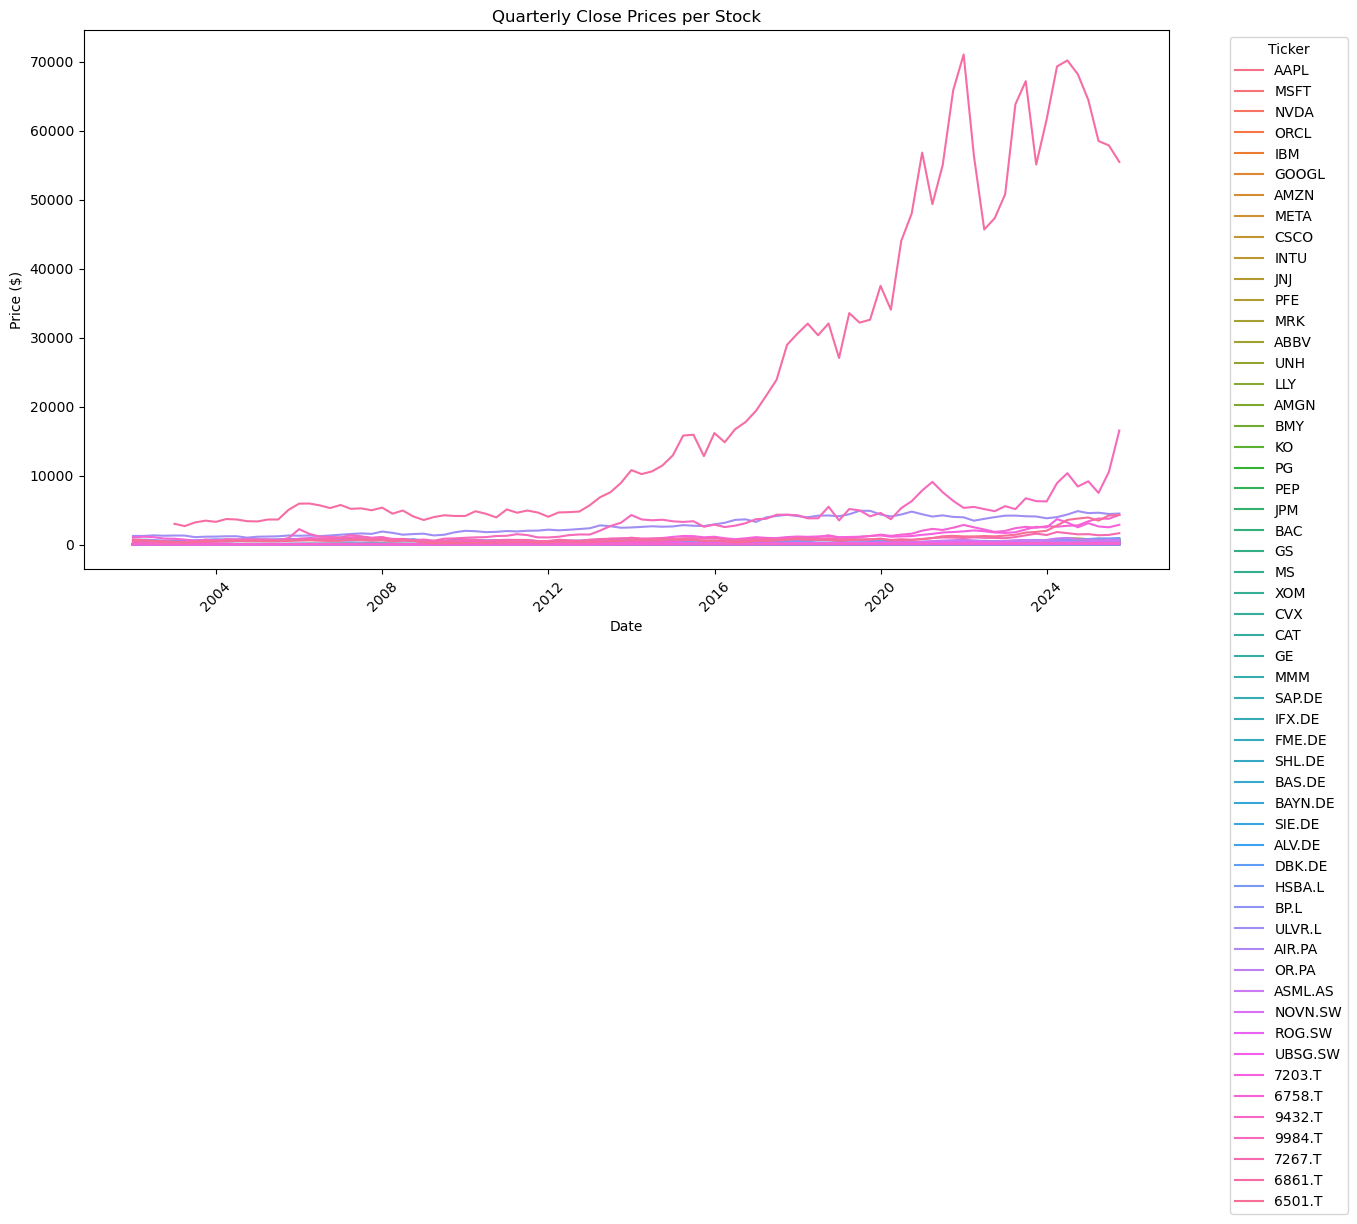

In [30]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='date', y='close', hue='ticker')
plt.title("Quarterly Close Prices per Stock")
plt.ylabel("Price ($)")
plt.xlabel("Date")
plt.xticks(rotation=45)
plt.legend(title='Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')

### 2. Missing data heatmap

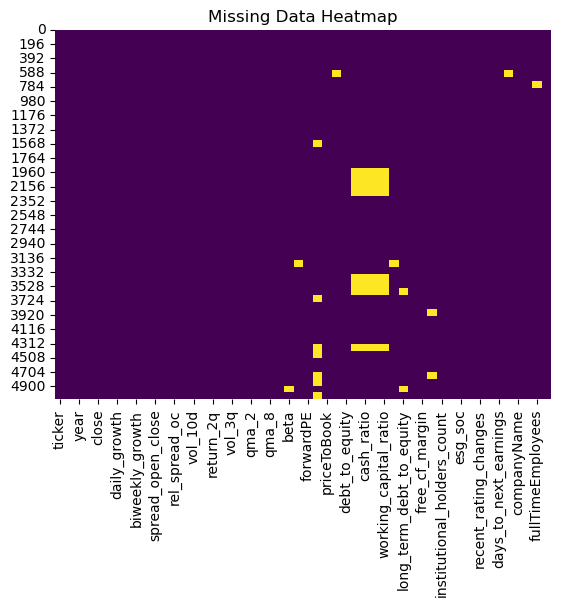

In [31]:
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [32]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='momentum_3q', y='vol_3q', hue='sector', style='country', s=100)
plt.axhline(df['vol_3q'].median(), linestyle='--', color='grey')
plt.axvline(df['momentum_3q'].median(), linestyle='--', color='grey')
plt.title('Momentum vs Volatility')
plt.xlabel('3Q Momentum')
plt.ylabel('3Q Volatility')
plt.grid(True)
plt.show()

ValueError: Could not interpret value `country` for `style`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

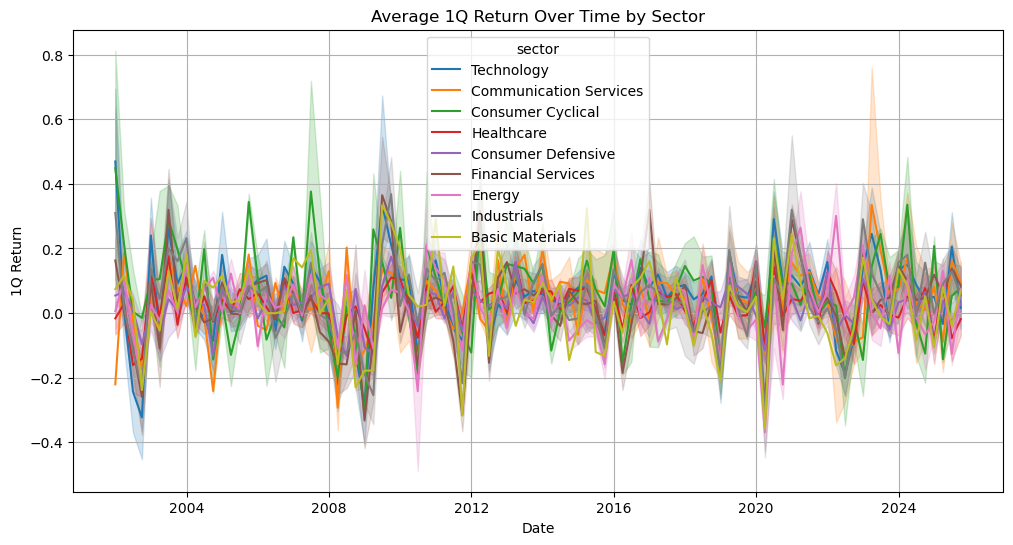

In [ ]:

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='return_1q', hue='sector', estimator='mean')
plt.title('Average 1Q Return Over Time by Sector')
plt.ylabel('1Q Return')
plt.xlabel('Date')
plt.grid(True)
plt.show()

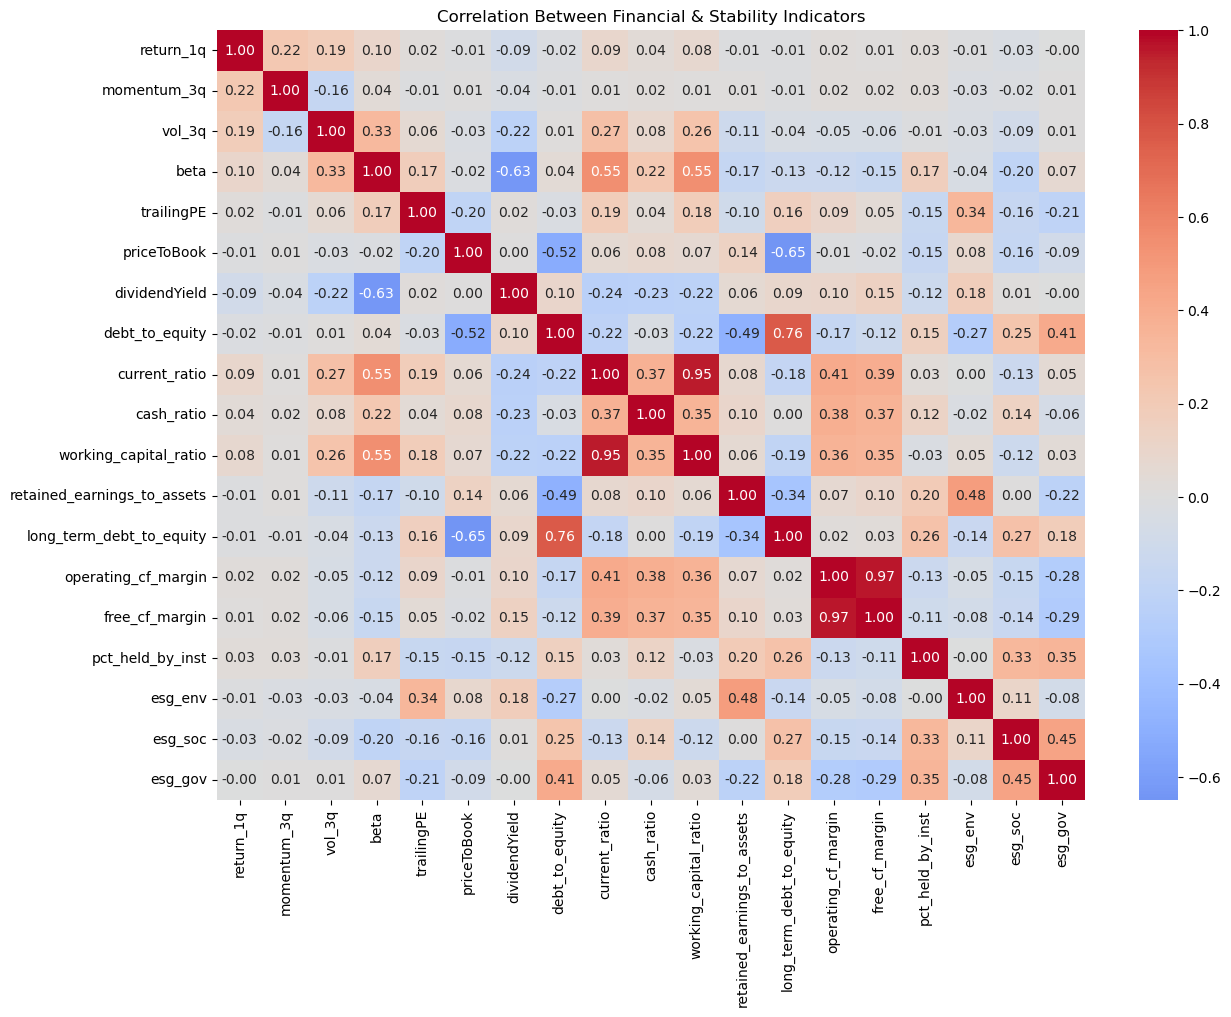

In [ ]:
numeric_cols = [
    'return_1q', 'momentum_3q', 'vol_3q',
    'beta', 'trailingPE', 'priceToBook', 'dividendYield',
    'debt_to_equity', 'current_ratio', 'cash_ratio', 'working_capital_ratio',
    'retained_earnings_to_assets', 'long_term_debt_to_equity',
    'operating_cf_margin', 'free_cf_margin', 'pct_held_by_inst',
    'esg_env', 'esg_soc', 'esg_gov'
]

plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation Between Financial & Stability Indicators")
plt.show()

In [ ]:
df.columns

Index(['ticker', 'date', 'year', 'quarter', 'close', 'return_1q', 'return_2q',
       'return_3q', 'vol_3q', 'momentum_3q', 'qma_2', 'qma_4', 'qma_8',
       'marketCap', 'beta', 'trailingPE', 'forwardPE', 'trailing_PEG',
       'priceToBook', 'dividendYield', 'debt_to_equity', 'current_ratio',
       'cash_ratio', 'working_capital', 'working_capital_ratio',
       'retained_earnings_to_assets', 'long_term_debt_to_equity',
       'operating_cf_margin', 'free_cf_margin', 'pct_held_by_inst',
       'institutional_holders_count', 'esg_env', 'esg_soc', 'esg_gov',
       'recent_rating_changes', 'strong_to_total_reco_ratio',
       'days_to_next_earnings', 'dividend_stability', 'companyName', 'sector',
       'industry', 'country', 'fullTimeEmployees'],
      dtype='object')

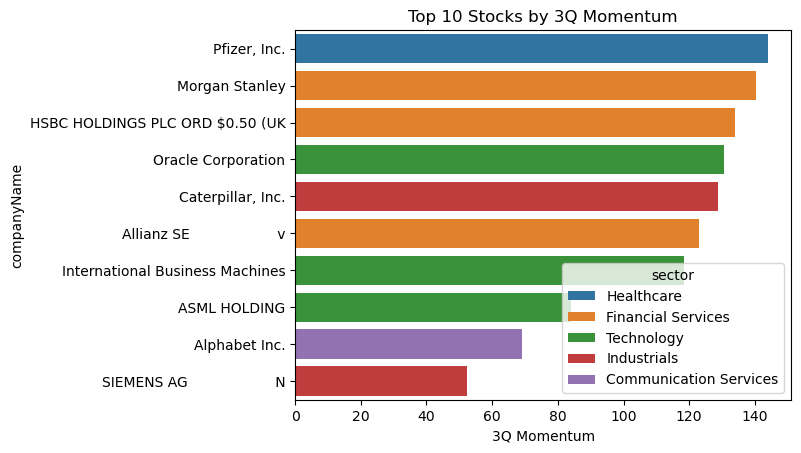

In [ ]:
top_momentum = df.sort_values('momentum_3q', ascending=False).drop_duplicates('ticker').head(10)
sns.barplot(data=top_momentum, x='momentum_3q', y='companyName', hue='sector')
plt.title('Top 10 Stocks by 3Q Momentum')
plt.xlabel('3Q Momentum')
plt.ylabel('companyName')
plt.show()

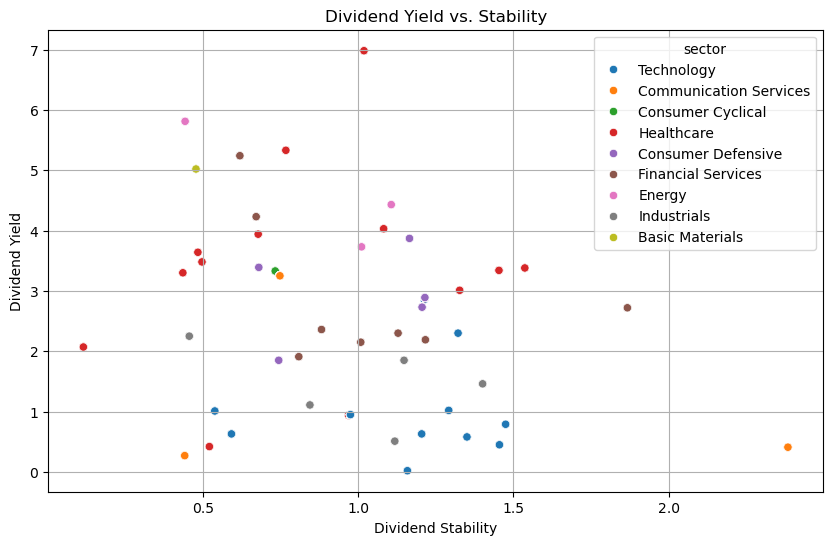

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='dividend_stability', y='dividendYield', hue='sector')
plt.title('Dividend Yield vs. Stability')
plt.xlabel('Dividend Stability')
plt.ylabel('Dividend Yield')
plt.grid(True)
plt.show()

In [ ]:
df

,ticker,date,year,quarter,close,return_1q,return_2q,return_3q,vol_3q,momentum_3q,...,esg_gov,recent_rating_changes,strong_to_total_reco_ratio,days_to_next_earnings,dividend_stability,companyName,sector,industry,country,fullTimeEmployees
0,AAPL,2001-12-31,2001,4,0.328720,0.411991,-0.058067,-0.007704,0.372535,-0.020680,...,8.58,183,0.120219,78,1.454838,Apple Inc.,Technology,Consumer Electronics,United States,150000
1,AAPL,2002-03-31,2002,1,0.355288,0.080825,0.526115,0.018064,0.373210,0.048402,...,8.58,183,0.120219,78,1.454838,Apple Inc.,Technology,Consumer Electronics,United States,150000
2,AAPL,2002-06-30,2002,2,0.265979,-0.251373,-0.190865,0.142491,0.331682,0.429602,...,8.58,183,0.120219,78,1.454838,Apple Inc.,Technology,Consumer Electronics,United States,150000
3,AAPL,2002-09-30,2002,3,0.217646,-0.181715,-0.387410,-0.337897,0.175183,-1.928824,...,8.58,183,0.120219,78,1.454838,Apple Inc.,Technology,Consumer Electronics,United States,150000
4,AAPL,2002-12-31,2002,4,0.215094,-0.011725,-0.191310,-0.394593,0.123275,-3.200925,...,8.58,183,0.120219,78,1.454838,Apple Inc.,Technology,Consumer Electronics,United States,150000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4693,9432.T,2024-09-30,2024,3,144.255478,-0.016029,-0.169723,-0.120675,0.109262,-1.104453,...,7.57,54,0.185185,85,0.747274,NTT INC,Communication Services,Telecom Services,Japan,341321
4694,9432.T,2024-12-31,2024,4,155.261337,0.076294,0.059042,-0.106378,0.117064,-0.908718,...,7.57,54,0.185185,85,0.747274,NTT INC,Communication Services,Telecom Services,Japan,341321
4695,9432.T,2025-03-31,2025,1,144.699997,-0.068023,0.003081,-0.012997,0.073092,-0.177819,...,7.57,54,0.185185,85,0.747274,NTT INC,Communication Services,Telecom Services,Japan,341321
4696,9432.T,2025-06-30,2025,2,154.000000,0.064271,-0.008124,0.067550,0.080077,0.843571,...,7.57,54,0.185185,85,0.747274,NTT INC,Communication Services,Telecom Services,Japan,341321


In [ ]:
df.columns

Index(['ticker', 'date', 'year', 'quarter', 'close', 'return_1q', 'return_2q',
       'return_3q', 'vol_3q', 'momentum_3q', 'qma_2', 'qma_4', 'qma_8',
       'marketCap', 'beta', 'trailingPE', 'forwardPE', 'trailing_PEG',
       'priceToBook', 'dividendYield', 'debt_to_equity', 'current_ratio',
       'cash_ratio', 'working_capital', 'working_capital_ratio',
       'retained_earnings_to_assets', 'long_term_debt_to_equity',
       'operating_cf_margin', 'free_cf_margin', 'pct_held_by_inst',
       'institutional_holders_count', 'esg_env', 'esg_soc', 'esg_gov',
       'recent_rating_changes', 'strong_to_total_reco_ratio',
       'days_to_next_earnings', 'dividend_stability', 'companyName', 'sector',
       'industry', 'country', 'fullTimeEmployees'],
      dtype='object')

In [ ]:
def plot_price_with_qma_signals(df, ticker):
    stock = df[df['ticker'] == ticker].copy()
    
    plt.figure(figsize=(14, 6))
    plt.plot(stock['date'], stock['close'], label='close', linewidth=2)
    plt.plot(stock['date'], stock['qma_2'], label='QMA2', linestyle='--')
    plt.plot(stock['date'], stock['qma_4'], label='QMA4', linestyle='--')
    plt.plot(stock['date'], stock['qma_8'], label='QMA8', linestyle=':')

    # Mark Buy signals
    plt.scatter(stock.loc[stock['buy_signal'], 'date'], 
                stock.loc[stock['buy_signal'], 'close'],
                marker='^', color='green', label='Buy Signal', zorder=5)
   

    plt.title(f'{df[df['ticker'] == ticker]['companyName'].values[0]}: Price with Quarterly Moving Averages')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
df.columns

Index(['ticker', 'date', 'year', 'quarter', 'close', 'return_1q', 'return_2q',
       'return_3q', 'vol_3q', 'momentum_3q', 'qma_2', 'qma_4', 'qma_8',
       'marketCap', 'beta', 'trailingPE', 'forwardPE', 'trailing_PEG',
       'priceToBook', 'dividendYield', 'debt_to_equity', 'current_ratio',
       'cash_ratio', 'working_capital', 'working_capital_ratio',
       'retained_earnings_to_assets', 'long_term_debt_to_equity',
       'operating_cf_margin', 'free_cf_margin', 'pct_held_by_inst',
       'institutional_holders_count', 'esg_env', 'esg_soc', 'esg_gov',
       'recent_rating_changes', 'strong_to_total_reco_ratio',
       'days_to_next_earnings', 'dividend_stability', 'companyName', 'sector',
       'industry', 'country', 'fullTimeEmployees'],
      dtype='object')

KeyError: 'buy_signal'

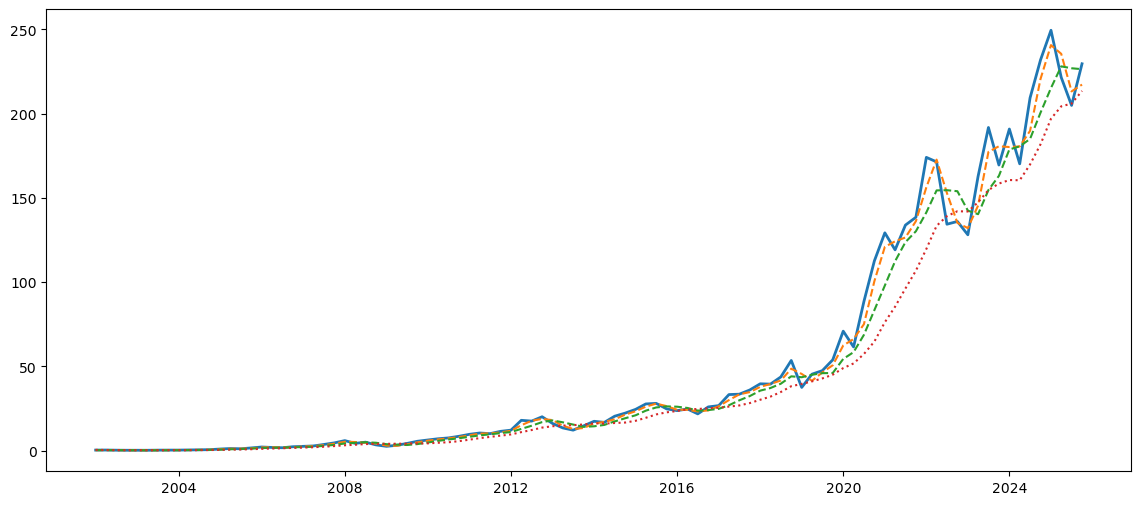

In [ ]:
for ticker in df['ticker'].unique():
    plot_price_with_qma_signals(df, ticker)